# 8주차 실습: 데이터 시각화 Seaborn

## 1. 환경 설정 및 데이터 로드

In [2]:
!pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 812.6 kB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import koreanize_matplotlib

import warnings
warnings.filterwarnings(action='ignore')

print(f'Seaborn 버전: {sns.__version__}')

Seaborn 버전: 0.13.2


In [4]:
tips = sns.load_dataset('tips')
penguins = sns.load_dataset('penguins')
flights = sns.load_dataset('flights')

print('=== tips 데이터셋 ===')
display(tips.head())
print(f'\n크기: {tips.shape}')

print('\n=== penguins 데이터셋 ===')
display(penguins.head())
print(f'\n크기: {penguins.shape}')

print('\n=== flights 데이터셋 ===')
display(flights.head())
print(f'\n크기: {flights.shape}')

=== tips 데이터셋 ===


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



크기: (244, 7)

=== penguins 데이터셋 ===


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



크기: (344, 7)

=== flights 데이터셋 ===


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121



크기: (144, 3)


## 2. Figure Level vs Axes Level

### 2.1 Figure Level: displot 기본 렌더링

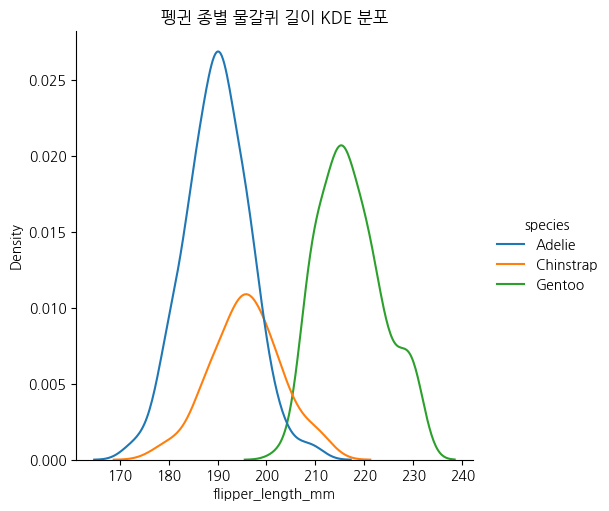

In [5]:
sns.displot(data=penguins,
            x='flipper_length_mm',
            hue='species',
            kind='kde')
plt.title('펭귄 종별 물갈퀴 길이 KDE 분포')
plt.show()

### 2.2 col 파라미터 기반 다중 패널 분할

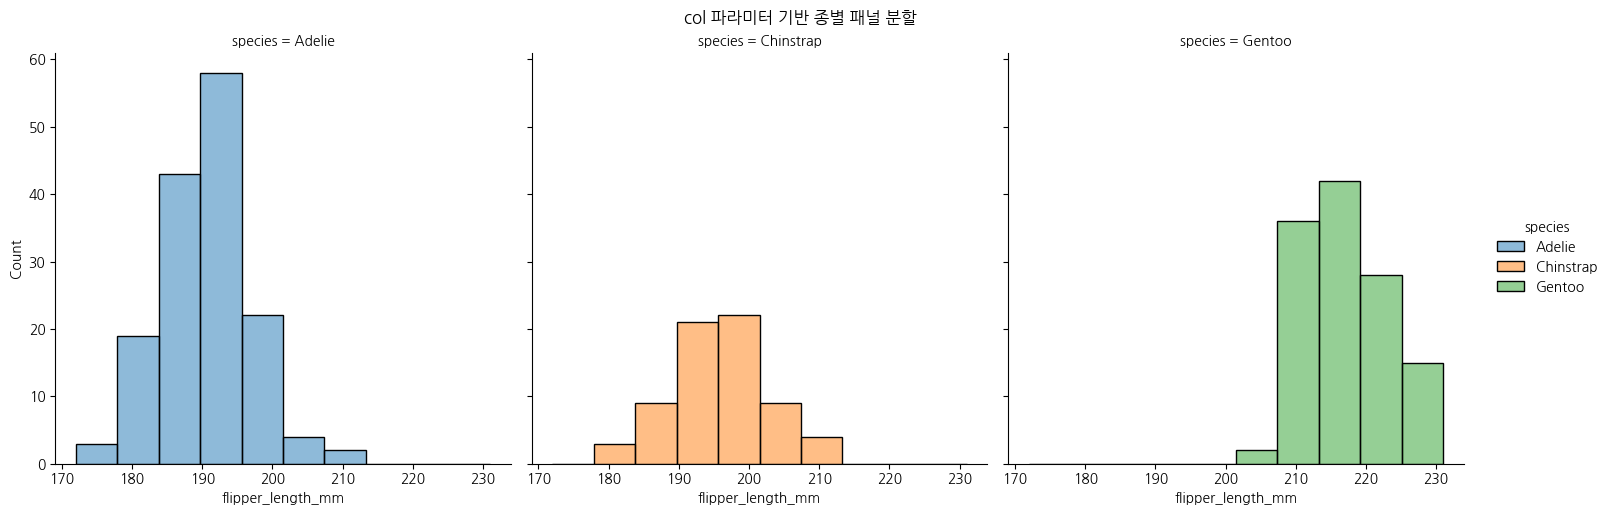

In [6]:
sns.displot(data=penguins,
            x='flipper_length_mm',
            col='species',
            hue='species')
plt.suptitle('col 파라미터 기반 종별 패널 분할', y=1.02)
plt.show()

### 2.3 Axes Level: Matplotlib 연동

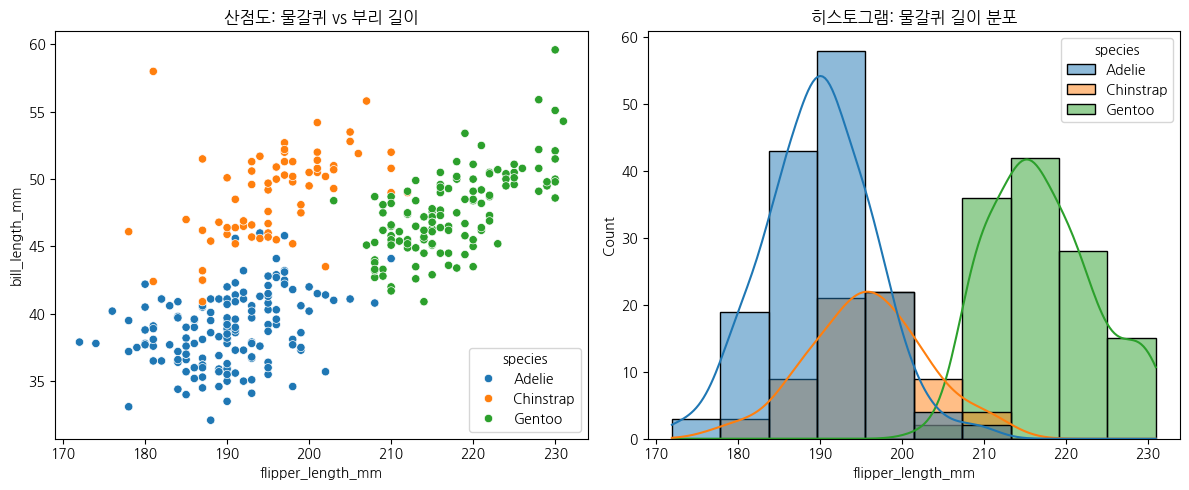

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=penguins,
                x='flipper_length_mm',
                y='bill_length_mm',
                hue='species',
                ax=axs[0])
axs[0].set_title('산점도: 물갈퀴 vs 부리 길이')

sns.histplot(data=penguins,
             x='flipper_length_mm',
             hue='species',
             kde=True,
             ax=axs[1])
axs[1].set_title('히스토그램: 물갈퀴 길이 분포')

plt.tight_layout()
plt.show()

### 2.4 시각적 가독성 최적화: alpha 파라미터

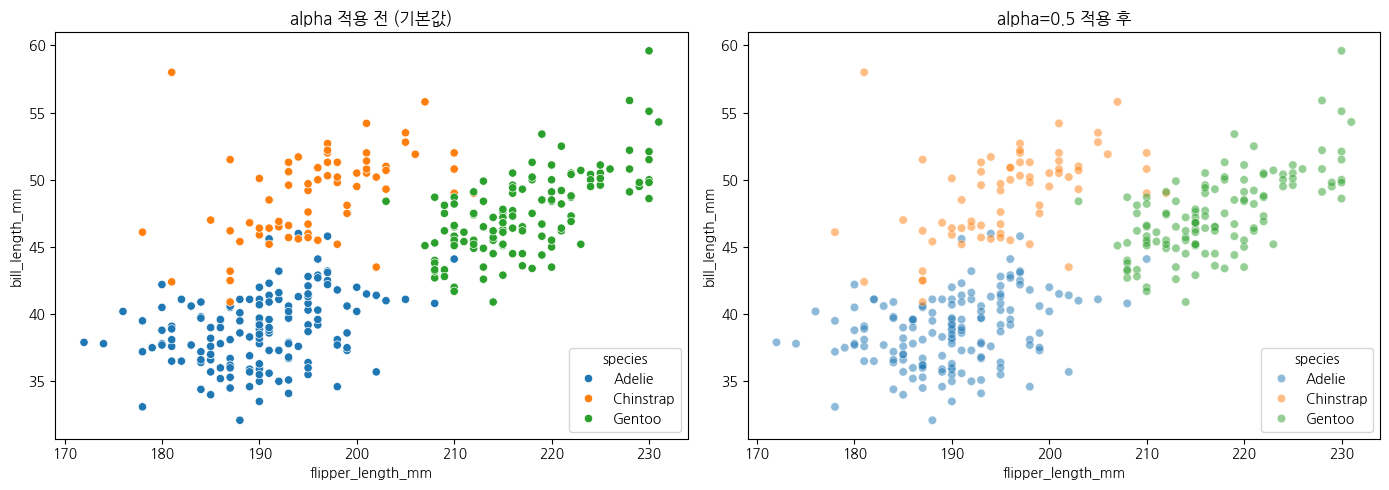

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=penguins,
                x='flipper_length_mm',
                y='bill_length_mm',
                hue='species',
                ax=axs[0])
axs[0].set_title('alpha 적용 전 (기본값)')

sns.scatterplot(data=penguins,
                x='flipper_length_mm',
                y='bill_length_mm',
                hue='species',
                alpha=0.5,
                ax=axs[1])
axs[1].set_title('alpha=0.5 적용 후')

plt.tight_layout()
plt.show()

## 3. Long-form vs Wide-form 시각화

### 3.1 Long-form 데이터 구조 확인 (Flights)

In [9]:
print('=== Long-form 데이터 구조 ===')
display(flights.head(10))
print(f'\n컬럼: {list(flights.columns)}')
print(f'크기: {flights.shape}')

=== Long-form 데이터 구조 ===


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119



컬럼: ['year', 'month', 'passengers']
크기: (144, 3)


### 3.2 Long-form 시각화: 연도별 성장 추이

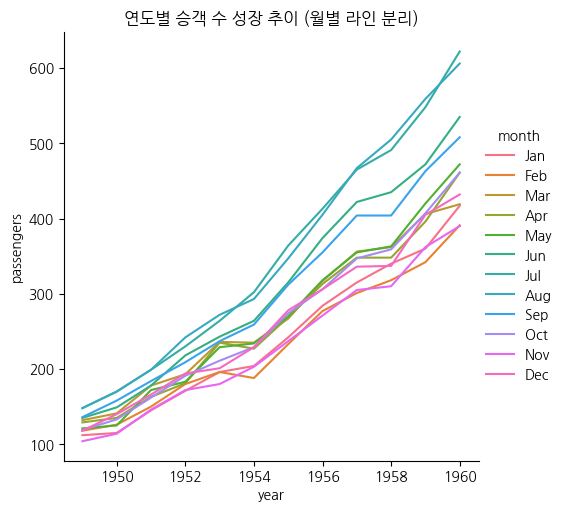

In [10]:
sns.relplot(data=flights,
            x='year',
            y='passengers',
            hue='month',
            kind='line')
plt.title('연도별 승객 수 성장 추이 (월별 라인 분리)')
plt.show()

### 3.3 시계열 패턴 발굴: 축 변환

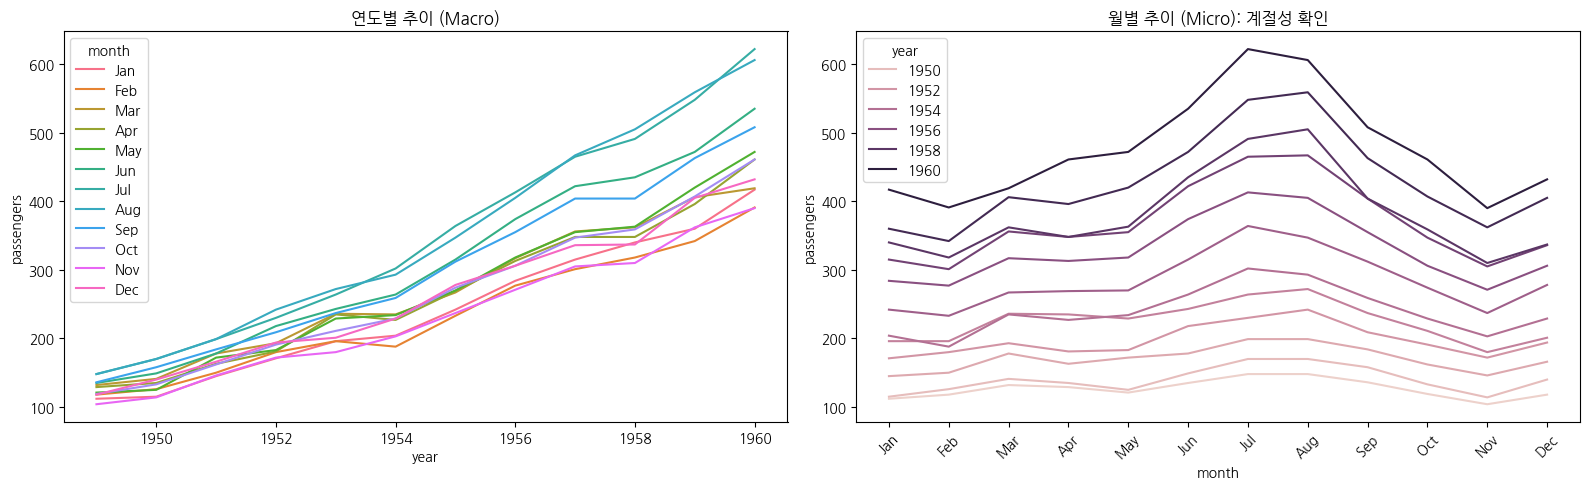

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', errorbar=None, ax=axs[0])
axs[0].set_title('연도별 추이 (Macro)')

sns.lineplot(data=flights, x='month', y='passengers',
             hue='year', errorbar=None, ax=axs[1])
axs[1].set_title('월별 추이 (Micro): 계절성 확인')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.4 분포 시각화: 박스 플롯(Boxplot)

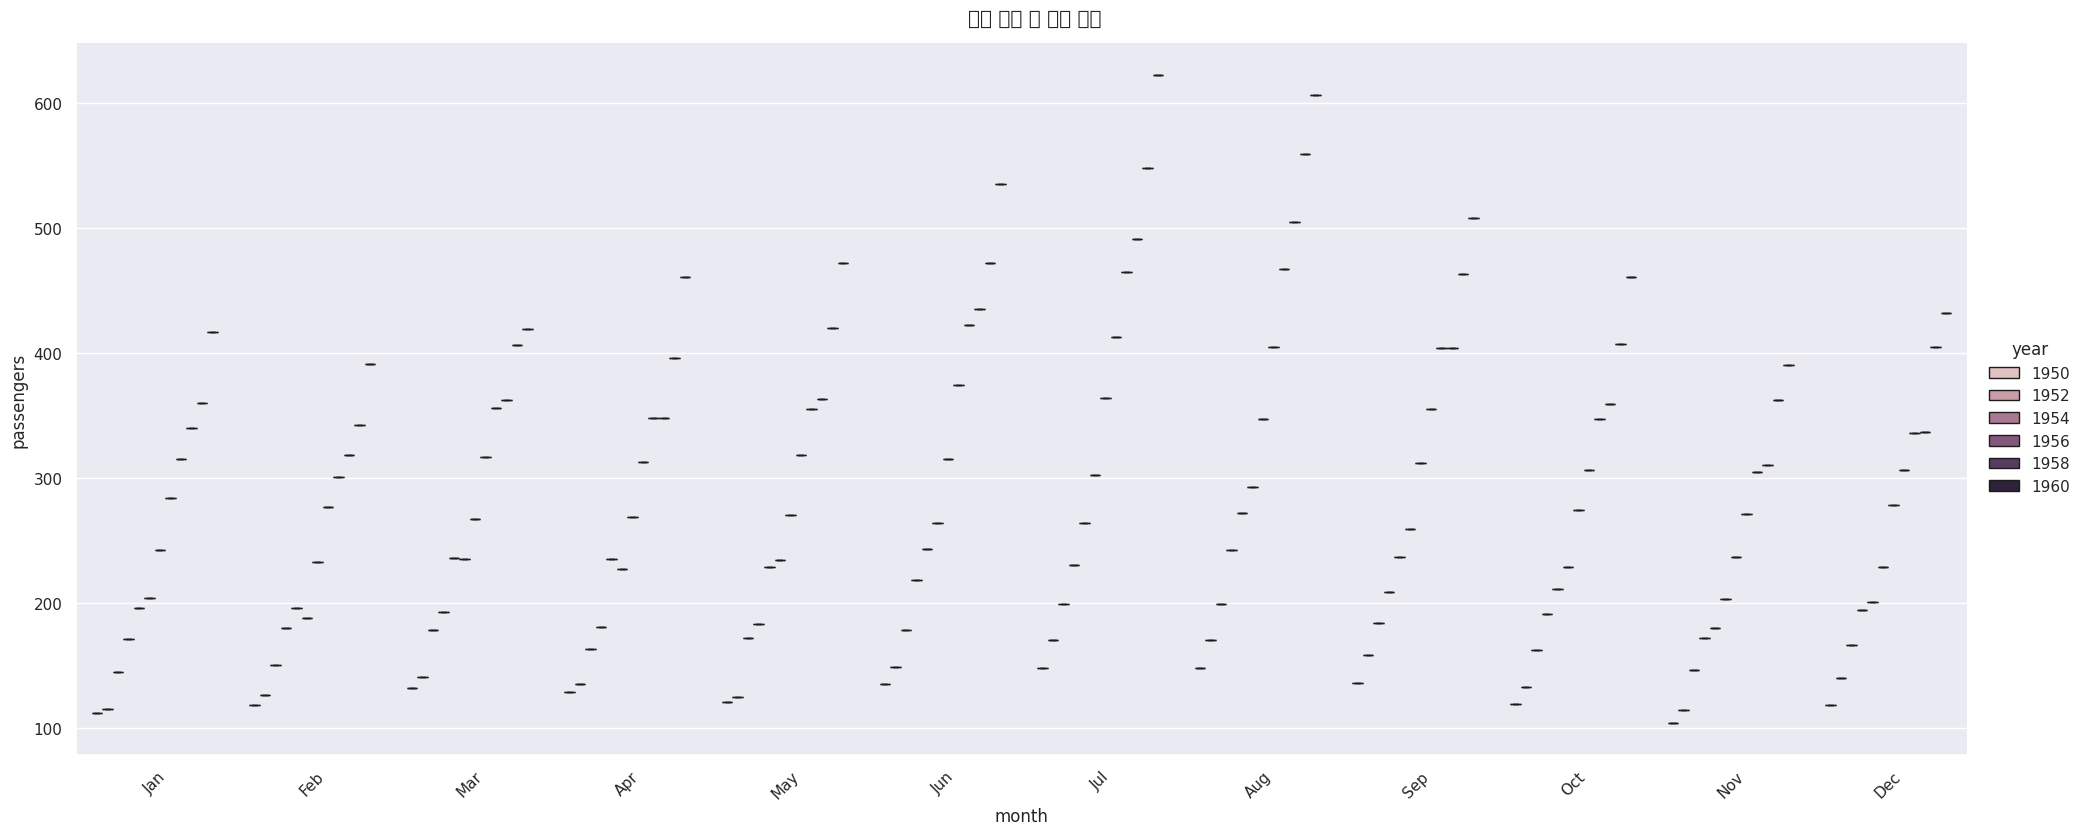

In [42]:
g = sns.catplot(data=flights,
                x='month',
                y='passengers',
                hue='year',
                kind='box',
                height=8,
                aspect=2.5,
                legend_out=True)
g.fig.suptitle('월별 승객 수 박스 플롯', y=1.02)
plt.xticks(rotation=45)
plt.show()

### 3.5 Wide-form 스키마 변환 (Pivot)

In [13]:
flights_wide = flights.pivot(index='year', columns='month', values='passengers')

print('=== Wide-form 데이터 구조 ===')
display(flights_wide.head())

=== Wide-form 데이터 구조 ===


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201


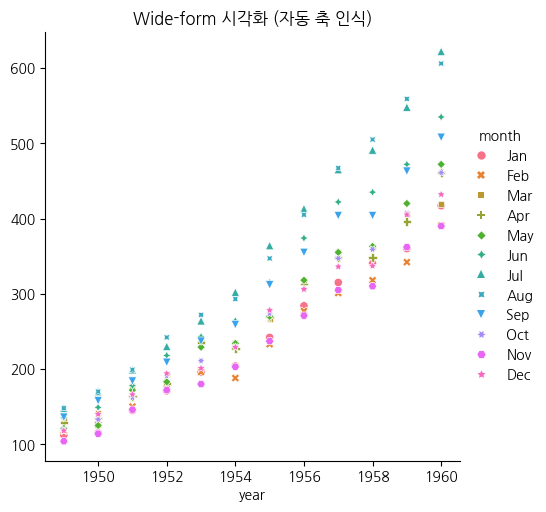

In [14]:
sns.relplot(data=flights_wide)
plt.title('Wide-form 시각화 (자동 축 인식)')
plt.show()

## 4. 라인 플롯 (Line Plot)

### 4.1 라인 플롯 기본 (신뢰 구간 포함/제거)

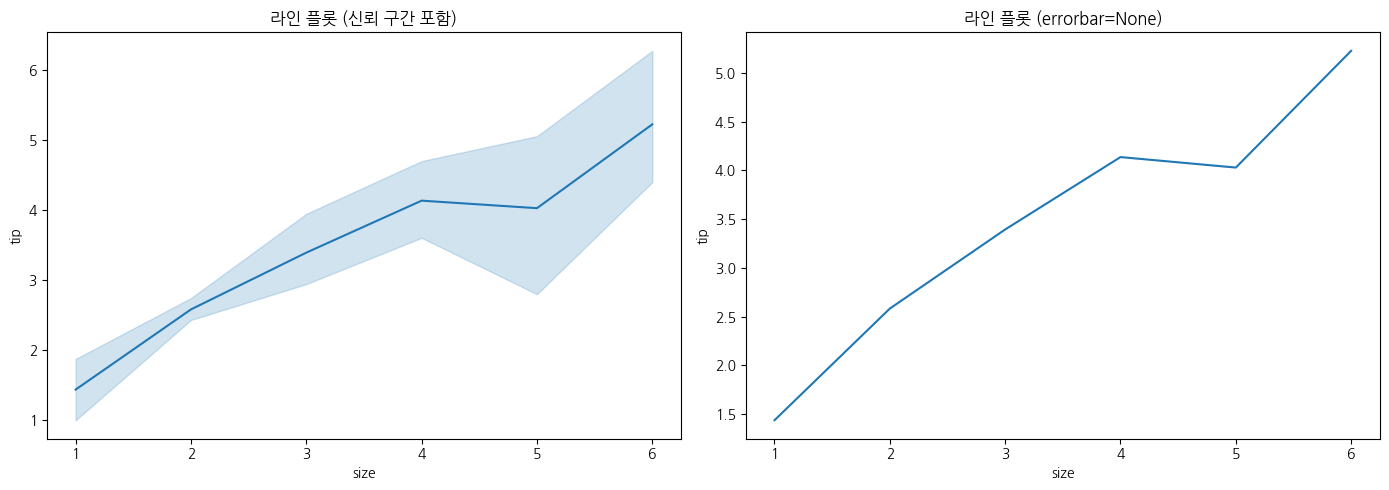

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x='size', y='tip', data=tips, ax=axs[0])
axs[0].set_title('라인 플롯 (신뢰 구간 포함)')

sns.lineplot(x='size', y='tip', data=tips, errorbar=None, ax=axs[1])
axs[1].set_title('라인 플롯 (errorbar=None)')

plt.tight_layout()
plt.show()

### 4.2 범주형 카테고리 분리: hue

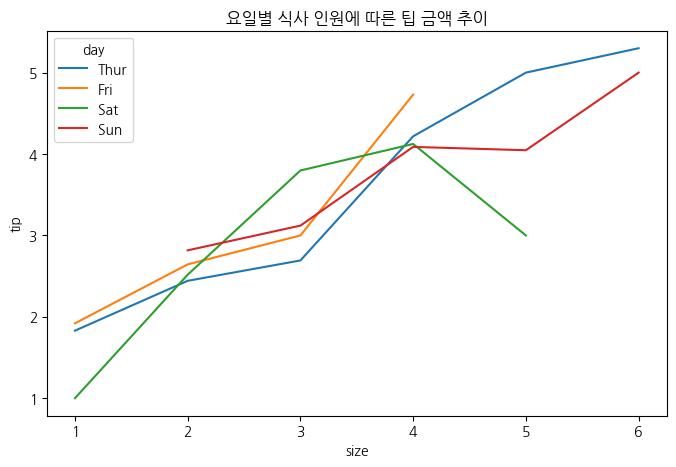

In [16]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='tip', hue='day', errorbar=None, data=tips)
plt.title('요일별 식사 인원에 따른 팁 금액 추이')
plt.show()

## 5. 분포 시각화: 히스토그램, KDE, Rug

### 5.1 순수 히스토그램

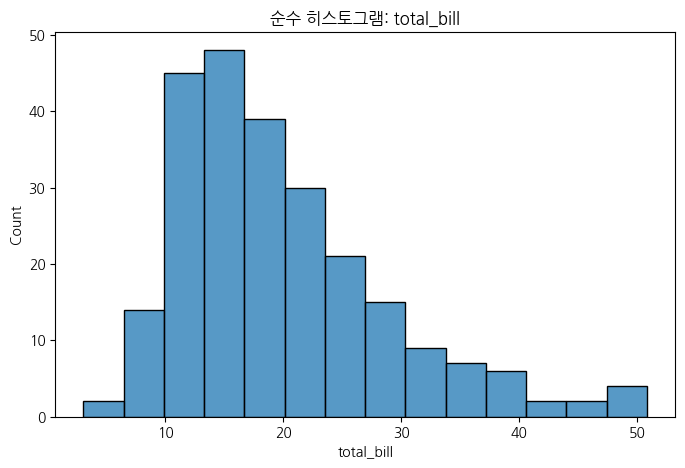

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(tips['total_bill'])
plt.title('순수 히스토그램: total_bill')
plt.show()

### 5.2 밀도 분포 포함 히스토그램 (kde=True)

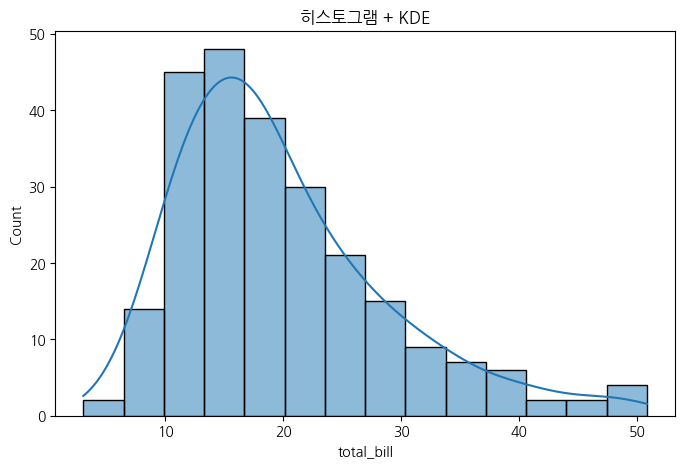

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(tips['total_bill'], kde=True)
plt.title('히스토그램 + KDE')
plt.show()

### 5.3 축 및 제목 제어 (Axes Level)

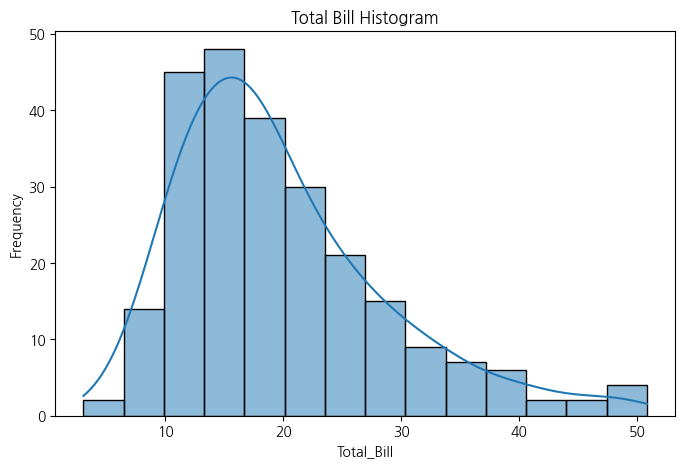

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(tips['total_bill'], kde=True, ax=ax)
ax.set_title('Total Bill Histogram')
ax.set_xlabel('Total_Bill')
ax.set_ylabel('Frequency')
plt.show()

### 5.4 KDE Plot

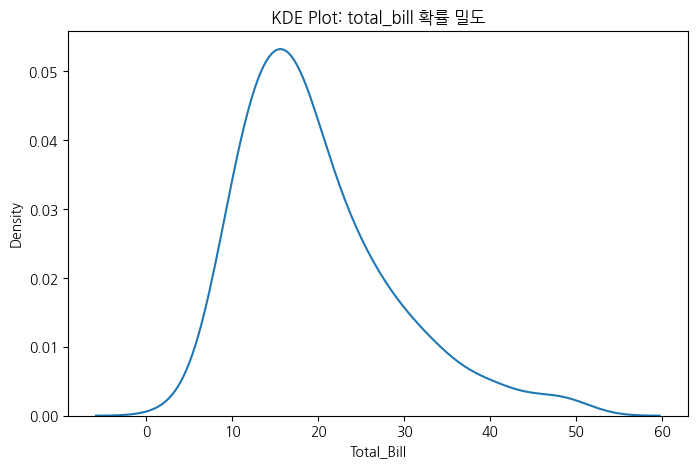

In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(tips['total_bill'])
plt.title('KDE Plot: total_bill 확률 밀도')
plt.xlabel('Total_Bill')
plt.show()

### 5.5 통합 밀도 시각화: 히스토그램 + KDE + Rug

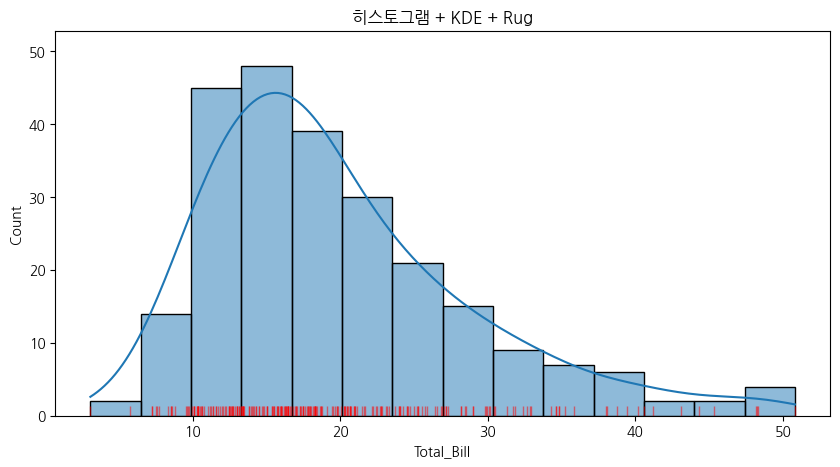

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(tips['total_bill'], kde=True, ax=ax)
sns.rugplot(tips['total_bill'], ax=ax, color='red', alpha=0.5)
ax.set_title('히스토그램 + KDE + Rug')
ax.set_xlabel('Total_Bill')
plt.show()

### 5.6 레이아웃 및 크기 조정

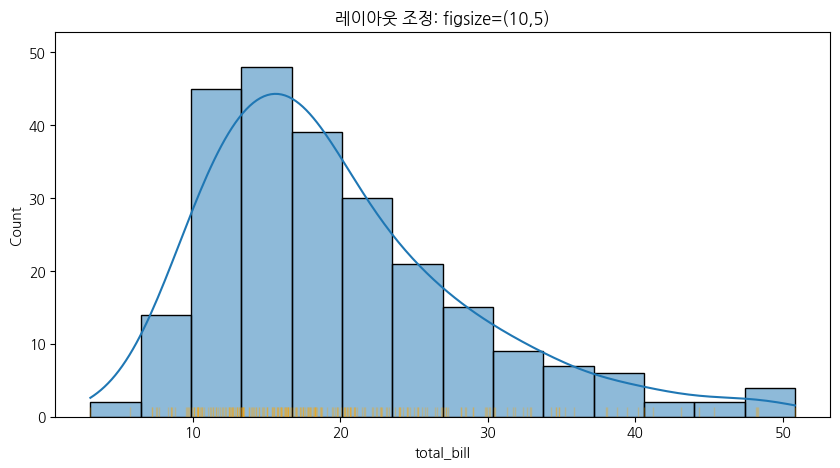

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(tips['total_bill'], kde=True, ax=ax)
sns.rugplot(tips['total_bill'], ax=ax, color='orange', alpha=0.3)
ax.set_title('레이아웃 조정: figsize=(10,5)')
plt.show()

## 6. 박스 그래프 (Box Plot)

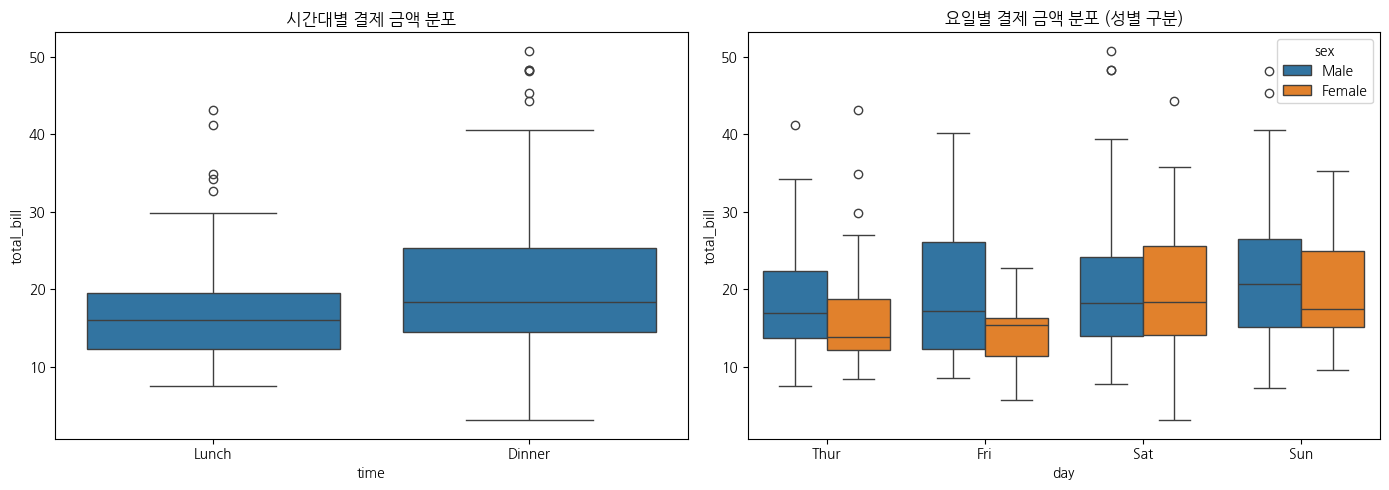

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='time', y='total_bill', data=tips, ax=axs[0])
axs[0].set_title('시간대별 결제 금액 분포')

sns.boxplot(x='day', y='total_bill', hue='sex', data=tips, ax=axs[1])
axs[1].set_title('요일별 결제 금액 분포 (성별 구분)')

plt.tight_layout()
plt.show()

## 7. 바이올린 그래프 (Violin Plot)

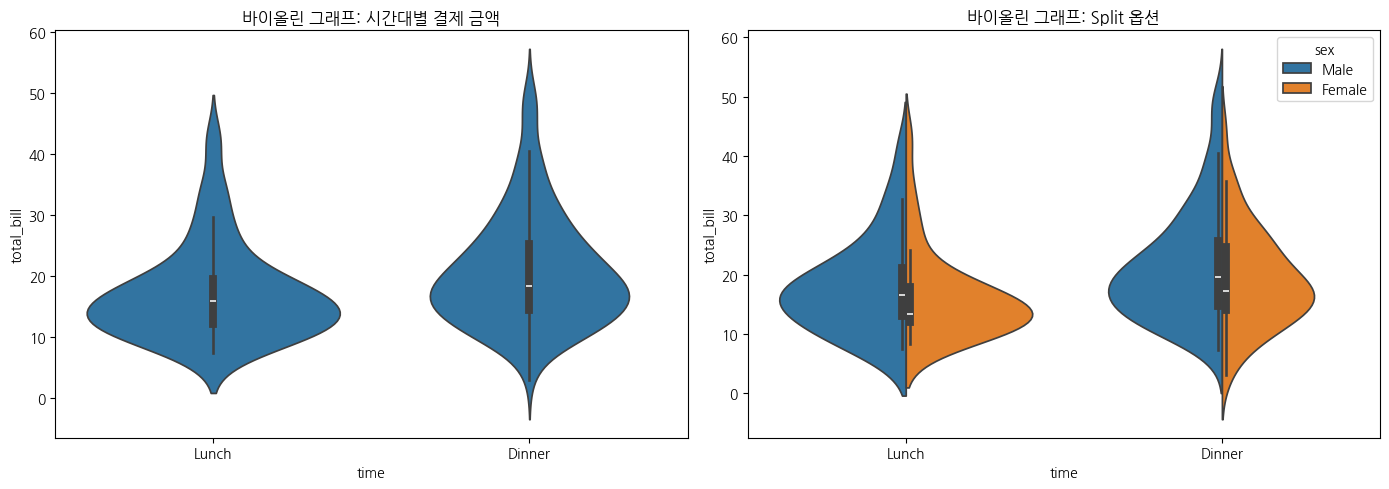

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(x='time', y='total_bill', data=tips, ax=axs[0])
axs[0].set_title('바이올린 그래프: 시간대별 결제 금액')

sns.violinplot(x='time', y='total_bill', hue='sex',
               split=True, data=tips, ax=axs[1])
axs[1].set_title('바이올린 그래프: Split 옵션')

plt.tight_layout()
plt.show()

## 8. 복합 변수 시각화: jointplot

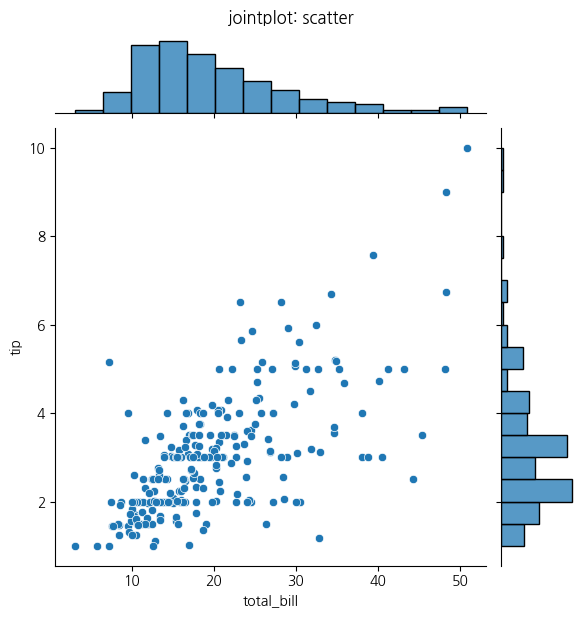

In [25]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='scatter')
plt.suptitle('jointplot: scatter', y=1.02)
plt.show()

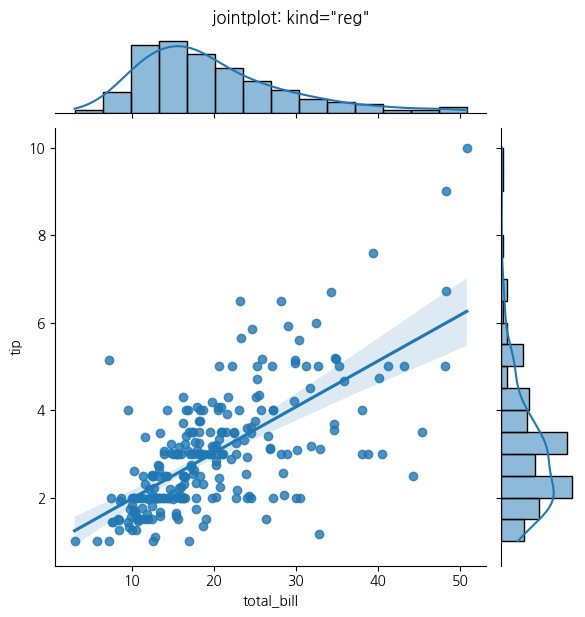

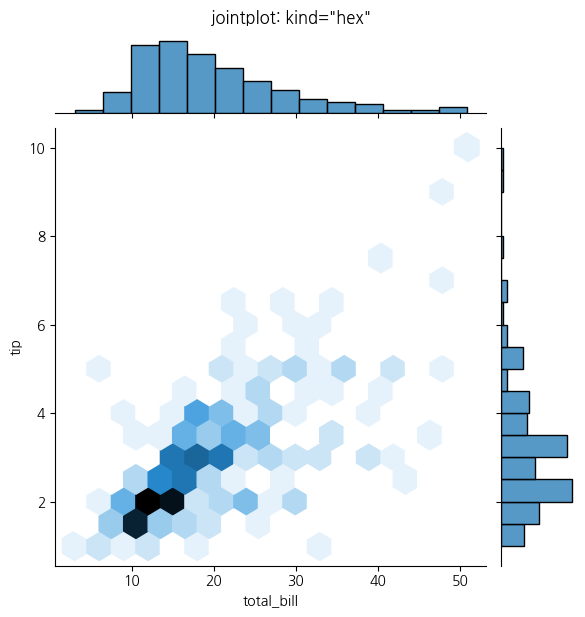

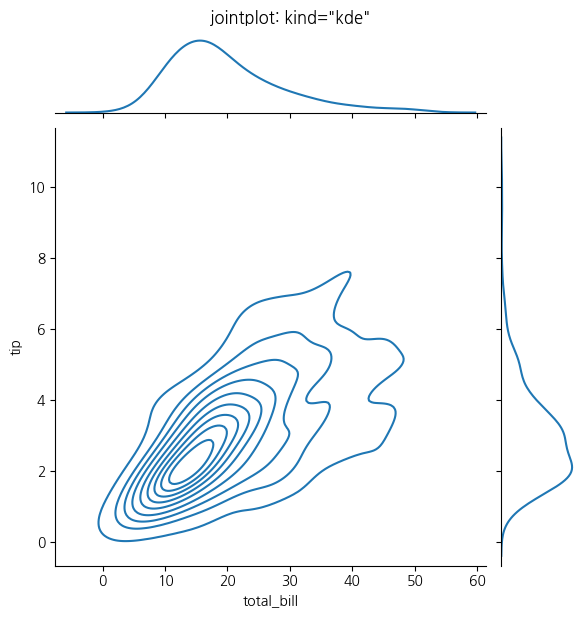

In [26]:
for k in ['reg', 'hex', 'kde']:
    sns.jointplot(x='total_bill', y='tip', data=tips, kind=k)
    plt.suptitle(f'jointplot: kind="{k}"', y=1.02)
    plt.show()

## 9. Pairplot & PairGrid

### 9.1 Pairplot 기본

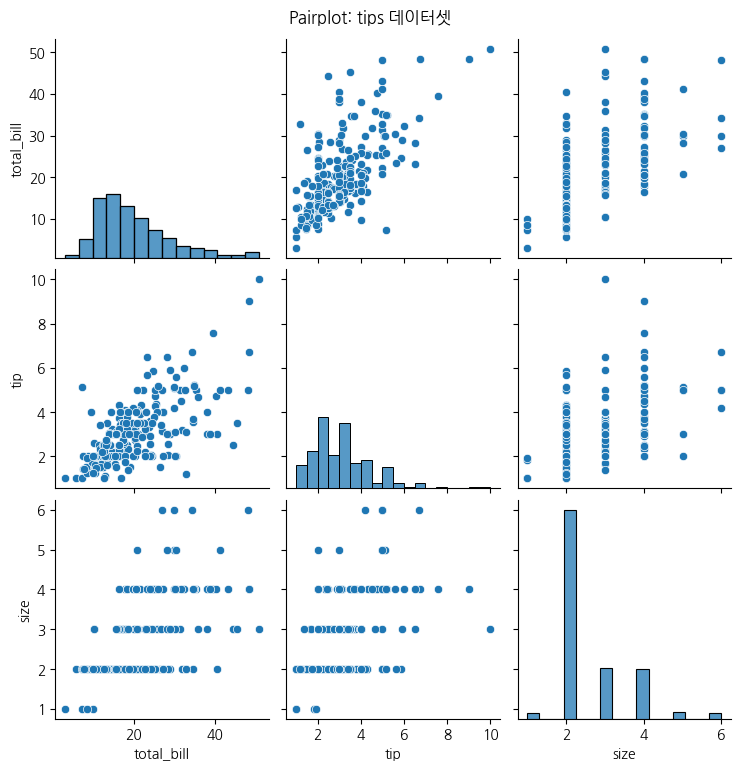

In [27]:
sns.pairplot(tips)
plt.suptitle('Pairplot: tips 데이터셋', y=1.02)
plt.show()

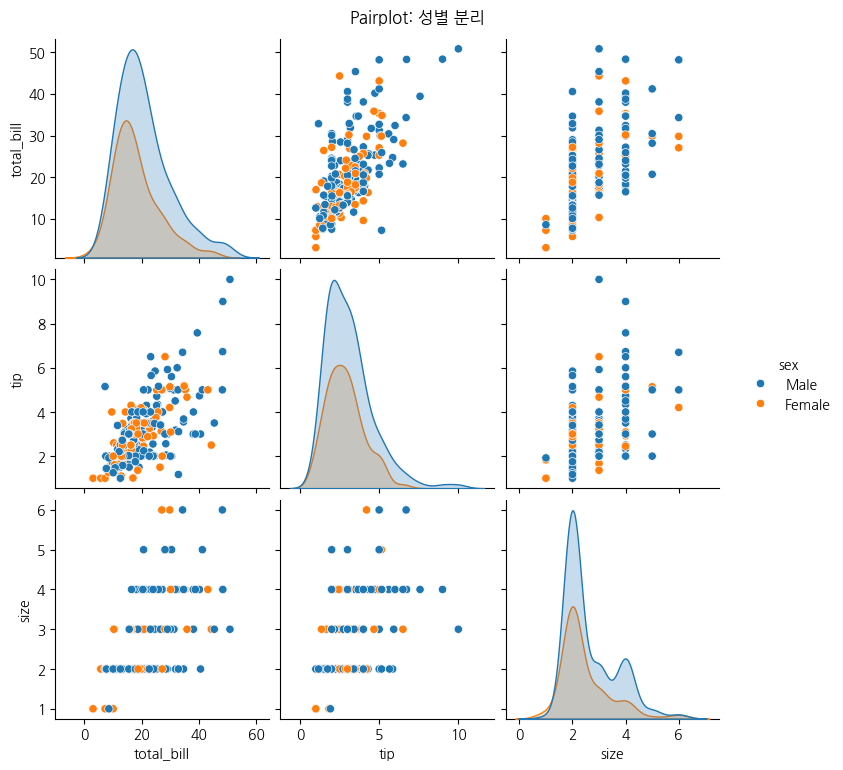

In [28]:
sns.pairplot(tips, hue='sex')
plt.suptitle('Pairplot: 성별 분리', y=1.02)
plt.show()

### 9.2 PairGrid 커스텀

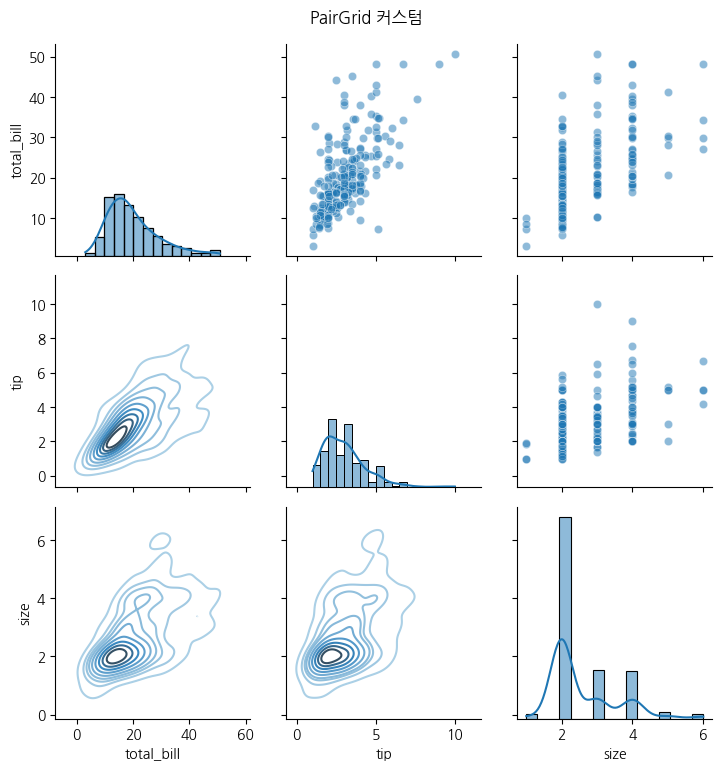

In [29]:
pair_grid = sns.PairGrid(tips)
pair_grid.map_diag(sns.histplot, kde=True)
pair_grid.map_upper(sns.scatterplot, alpha=0.5)
pair_grid.map_lower(sns.kdeplot, cmap='Blues_d')
plt.suptitle('PairGrid 커스텀', y=1.02)
plt.show()

## 10. Heat Map

### 10.1 데이터 준비: pivot_table

In [30]:
pivot_tips = tips.pivot_table(index='day',
                              columns='size',
                              values='tip')
display(pivot_tips)
print(f'\n결측치 확인:\n{pivot_tips.isnull().sum()}')

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0



결측치 확인:
size
1    1
2    0
3    0
4    0
5    1
6    2
dtype: int64


### 10.2 Heat Map 결측치 확인 및 처리

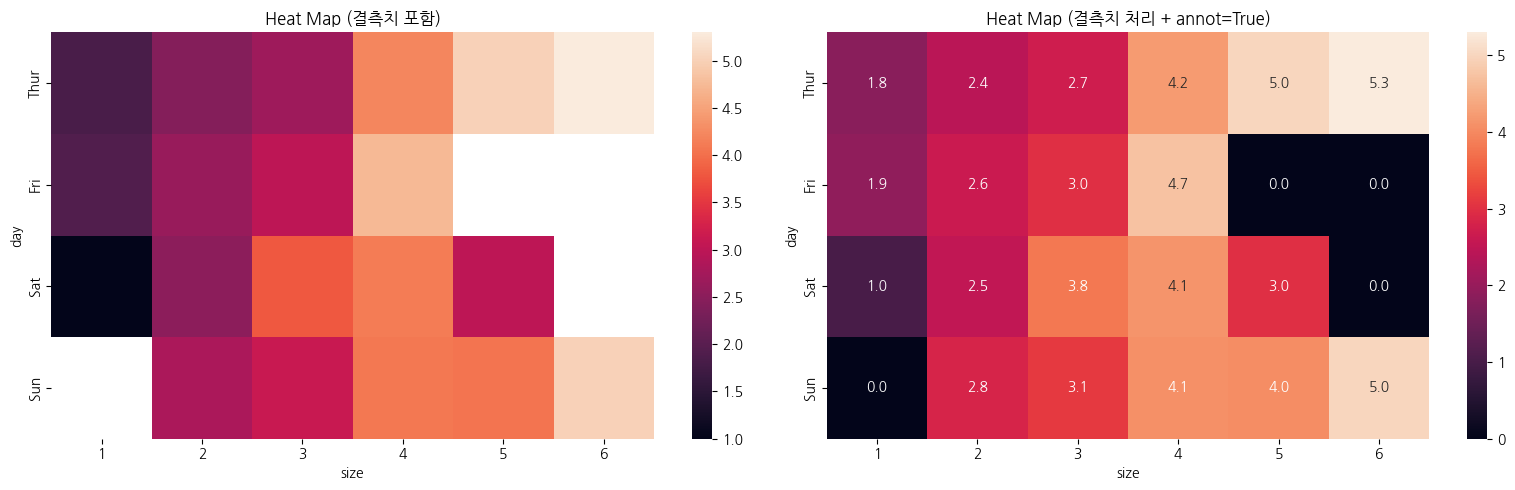

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_tips, ax=axs[0])
axs[0].set_title('Heat Map (결측치 포함)')

pivot_tips_filled = pivot_tips.fillna(0)
sns.heatmap(pivot_tips_filled, annot=True, fmt='.1f', ax=axs[1])
axs[1].set_title('Heat Map (결측치 처리 + annot=True)')

plt.tight_layout()
plt.show()

### 10.3 Flights 히트맵

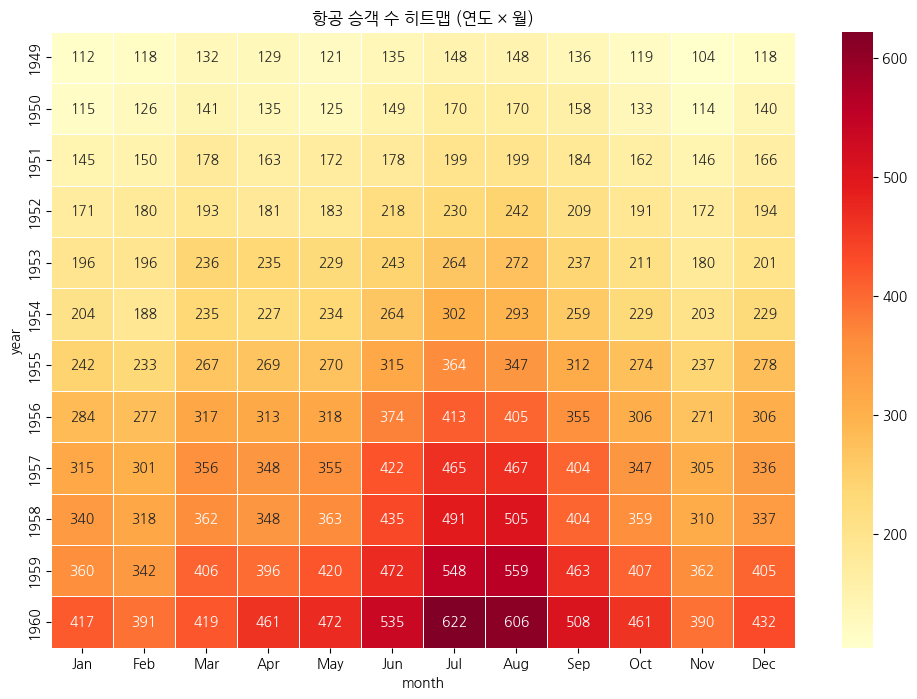

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(flights_wide,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('항공 승객 수 히트맵 (연도 × 월)')
plt.show()

## 11. 다변량 바이올린 그래프

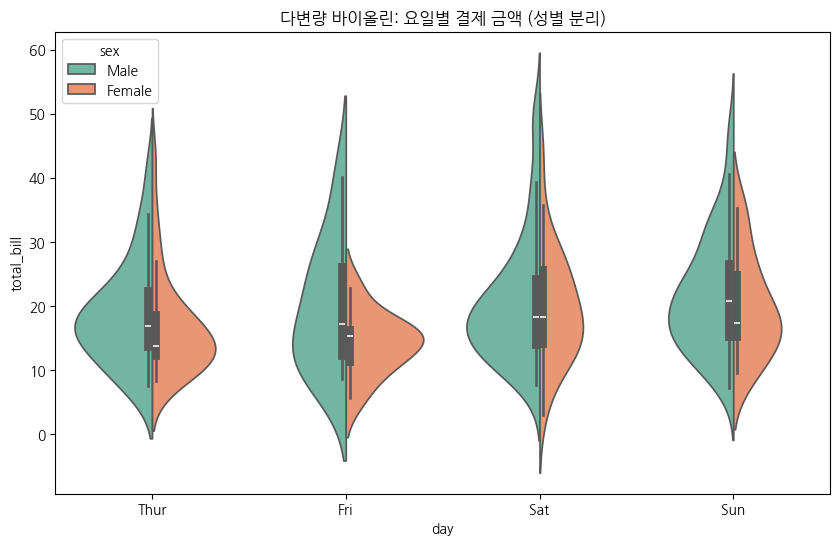

In [33]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='day', y='total_bill', hue='sex',
               split=True, data=tips, palette='Set2')
plt.title('다변량 바이올린: 요일별 결제 금액 (성별 분리)')
plt.show()

## 12. FacetGrid

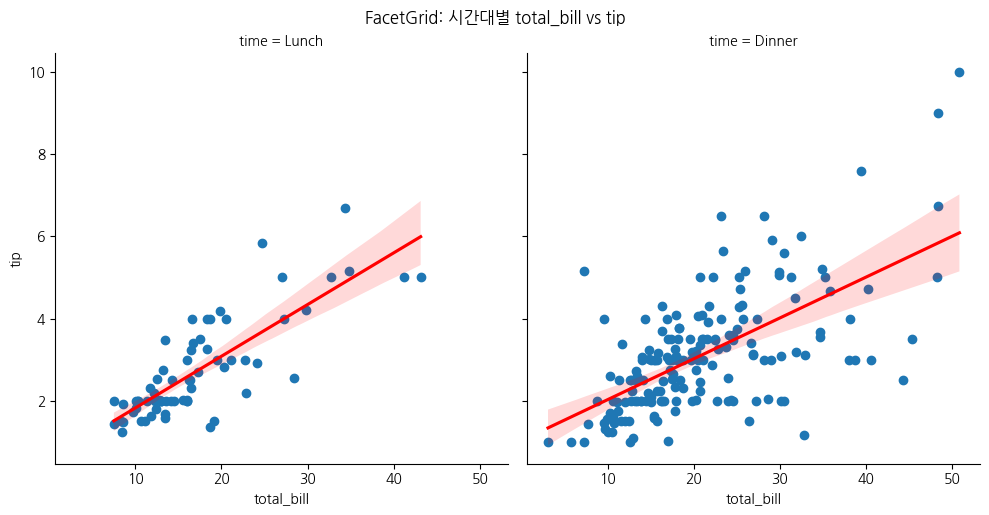

In [34]:
facet = sns.FacetGrid(tips, col='time', height=5)
facet.map(plt.scatter, 'total_bill', 'tip')
facet.map(sns.regplot, 'total_bill', 'tip',
          scatter=False, color='red')
plt.suptitle('FacetGrid: 시간대별 total_bill vs tip', y=1.02)
plt.show()

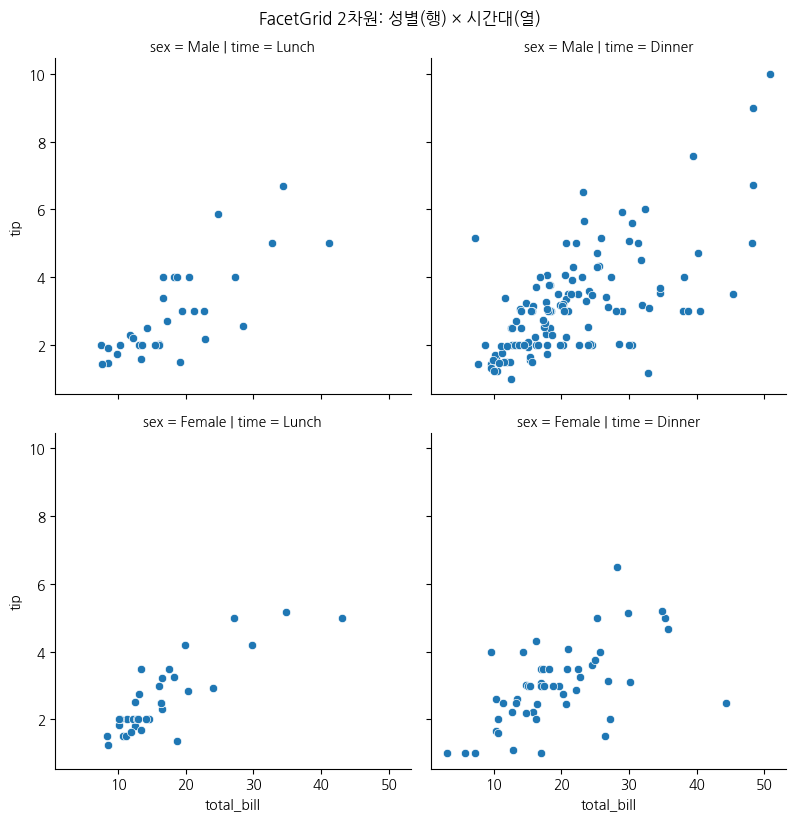

In [35]:
facet2 = sns.FacetGrid(tips, row='sex', col='time', height=4)
facet2.map(sns.scatterplot, 'total_bill', 'tip')
facet2.add_legend()
plt.suptitle('FacetGrid 2차원: 성별(행) × 시간대(열)', y=1.02)
plt.show()

## 13. 서브플롯 대시보드

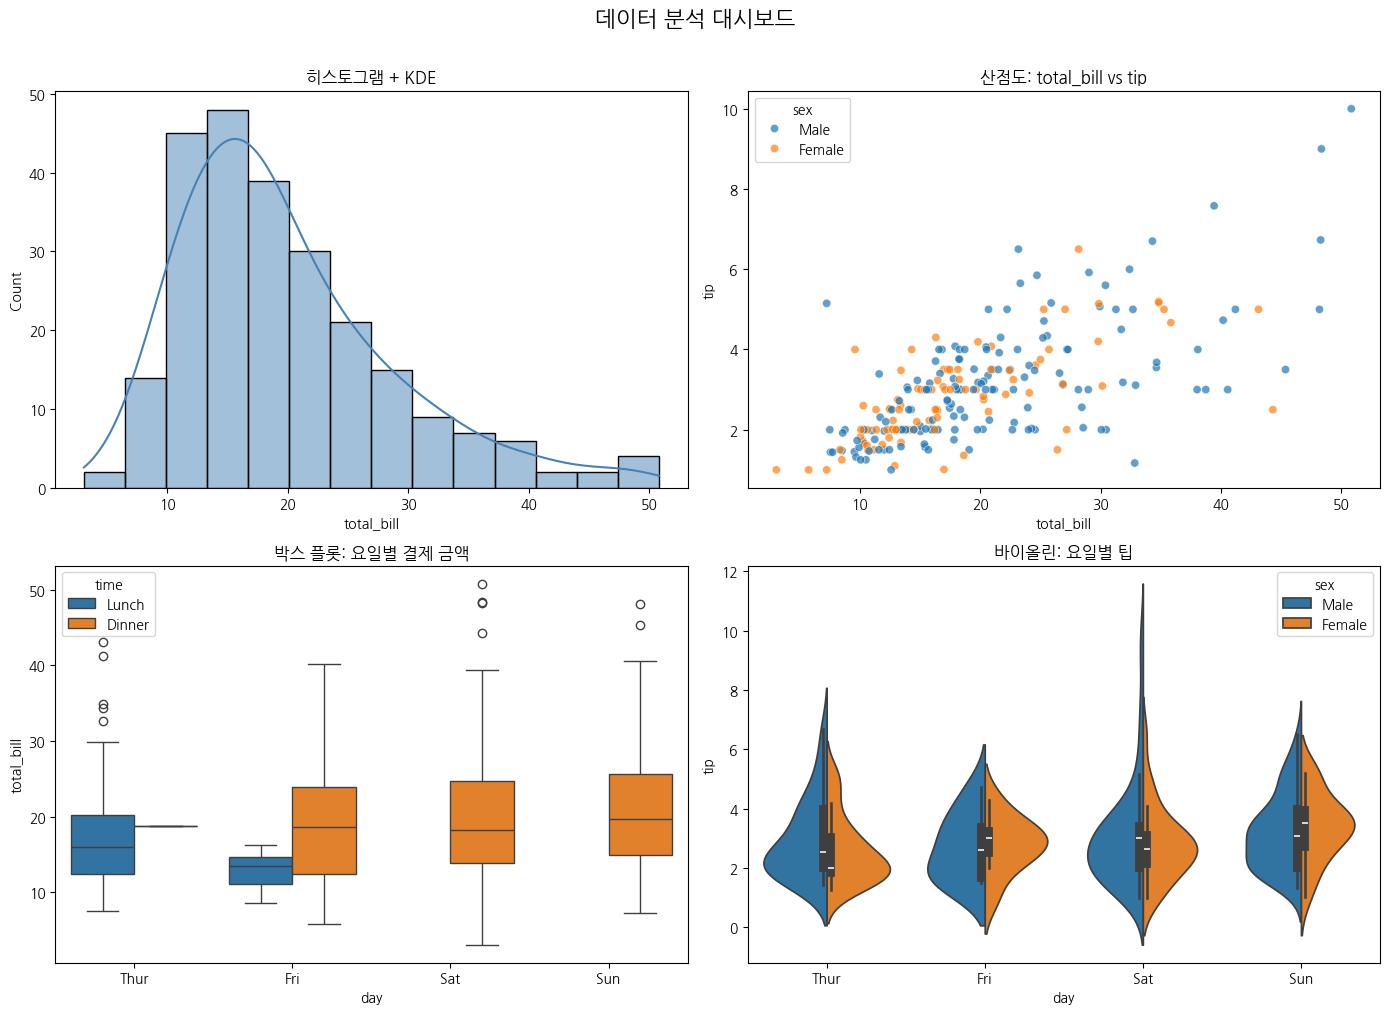

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(tips['total_bill'], kde=True, ax=ax[0, 0], color='steelblue')
ax[0, 0].set_title('히스토그램 + KDE')

sns.scatterplot(x='total_bill', y='tip', hue='sex',
                data=tips, ax=ax[0, 1], alpha=0.7)
ax[0, 1].set_title('산점도: total_bill vs tip')

sns.boxplot(x='day', y='total_bill', hue='time',
            data=tips, ax=ax[1, 0])
ax[1, 0].set_title('박스 플롯: 요일별 결제 금액')

sns.violinplot(x='day', y='tip', hue='sex',
               split=True, data=tips, ax=ax[1, 1])
ax[1, 1].set_title('바이올린: 요일별 팁')

plt.suptitle('데이터 분석 대시보드', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 14. 스타일 및 테마 설정

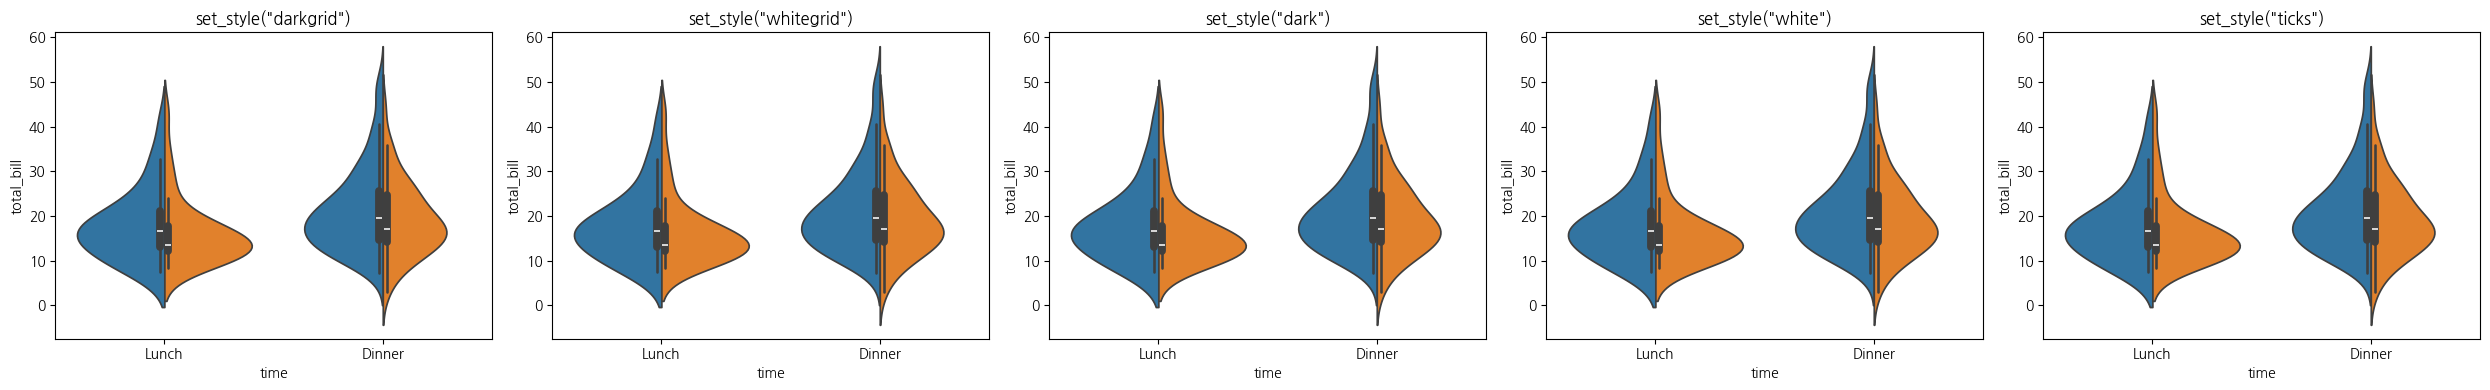

In [37]:
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

fig, axs = plt.subplots(1, 5, figsize=(25, 4))

for i, style in enumerate(styles):
    sns.set_style(style)
    sns.violinplot(x='time', y='total_bill', hue='sex',
                   split=True, data=tips, ax=axs[i])
    axs[i].set_title(f'set_style("{style}")')
    axs[i].legend([], [], frameon=False)

plt.tight_layout()
plt.show()

sns.set_style('darkgrid')